In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r'C:\Users\indur\OneDrive\Desktop\power bi projects\Public_Transport_Delay\ETL\-Smart-Traffic-Accident-Risk-Prediction-System-Using-Machine-Learning\DATA\cleaned_smart_accident.csv')
df

,Unnamed: 0,WEATHER_CONDITION,VISIBILITY,TRAFFIC_DENSITY,VEHICLE_SPEED,ROAD_CONDITION,HOUR,SPEED_LIMIT,ROAD_TYPE,PRECIPITATION,JUNCTION,TRAFFIC_SIGNAL,ACCIDENT_OCCURRENCE
0,0,Clearsky,4.5,Lowtraffic,31,Muddy,6,40,Serviceroad,Snowfall,0,1,0
1,1,Sunny,7.0,Meddensity,74,Icy,7,70,Expressway,Heavyrain,0,1,1
2,2,Storm,10.0,Light,110,Dryroad,12,50,Rural,Heavyrain,0,0,0
3,3,Clearsky,3.0,Meddensity,108,Waterwater,1,80,Expressway,Snowfall,1,0,0
4,4,Misty,13.8,Hgh,115,Muddy,7,60,Urbanroad,Snowfall,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,59995,Misty,10.0,High,10,Waterwater,12,50,Bridgelane,Fogdrizzle,0,0,0
59996,59996,Rainy,10.0,Medtraffic,100,Dryroad,23,50,Highway,Norain,1,0,0
59997,59997,Snow,9.1,Jampacked,59,Roughroad,12,70,City,Lightrain,1,0,1
59998,59998,Foggy,4.8,Low,49,Dryroad,3,100,Serviceroad,Lightrain,0,0,1


In [ ]:
# EXPLORETARY OF DATA ANALYSIS

In [ ]:
# STEP 1 BASIC  EDA TO UNDERSTAND THE DATA

print('statical summery')
print(df.describe().to_string())

print('information of data like dtypes,columns,null numbers')
print(df.info())

print('check dimensionality')
print(df.shape)

print('columns')
print(df.columns)



In [ ]:
# STEP 2 CHECK DUPLICATES

print('Check Duplicates')
print(df.duplicated().sum())

print('Removing Duplicates')
print(df.drop_duplicates(df).to_string())

In [ ]:
# STEP 3 CHECK MISSING VALUES

print('Checking messing values')
print(df.isnull().sum())

In [ ]:
# STEP 4
print('Checking Imbalance')
imbalance = df['ACCIDENT_OCCURRENCE'].value_counts(normalize=True)*100
print(imbalance)


In [ ]:
# STEP 5 UNDERSTANDING CATEGORICAL COLUMNS

categorical = df.groupby(['WEATHER_CONDITION','TRAFFIC_DENSITY','ROAD_CONDITION','ROAD_TYPE']).agg({

    'SPEED_LIMIT':'mean',
    'ACCIDENT_OCCURRENCE':'mean'
})

print(categorical.head().to_string())

ROAD_TYPE
Bridgelane    0.502027
City          0.508723
Expressway    0.502756
Highway       0.500887
Rural         0.498655


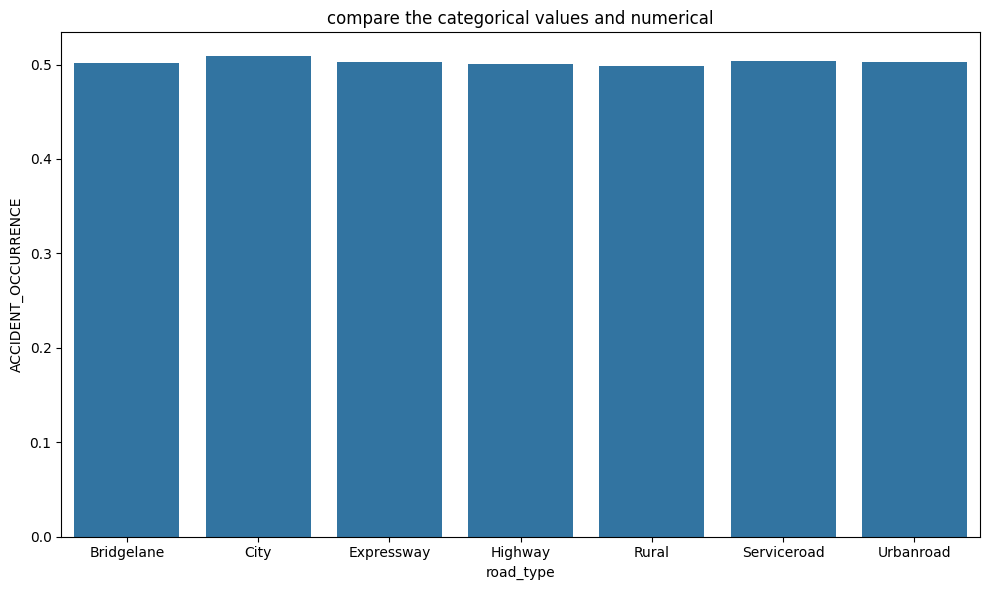

In [ ]:
# STEP 6 UNDERSTANDING NUMERICAL DATA


numerical = df.groupby('ROAD_TYPE')['ACCIDENT_OCCURRENCE'].mean()
print(numerical.head().to_string())

plt.figure(figsize=(10,6))
sns.barplot(numerical)
plt.title('compare the categorical values and numerical')
plt.xlabel('road_type')
plt.ylabel('ACCIDENT_OCCURRENCE')
plt.tight_layout()
plt.show()

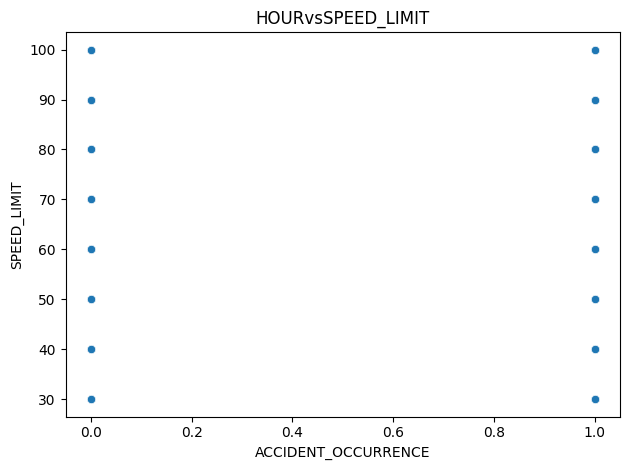

In [17]:
#STEP 7 RELATIONSHIP PLOT
plt.Figure(figsize=(10,6))
sns.scatterplot(x='ACCIDENT_OCCURRENCE',y='SPEED_LIMIT',data=df)
plt.title('HOUR' 'vs' 'SPEED_LIMIT')
plt.xlabel('ACCIDENT_OCCURRENCE')
plt.ylabel('SPEED_LIMIT')
plt.tight_layout()

plt.show()

Checking correlation between numerical features
      Unnamed: 0  VISIBILITY  VEHICLE_SPEED  HOUR  SPEED_LIMIT  JUNCTION  TRAFFIC_SIGNAL  ACCIDENT_OCCURRENCE
HOUR   -0.001293    0.000431       0.001523   1.0    -0.005573 -0.001956        0.002386            -0.004008


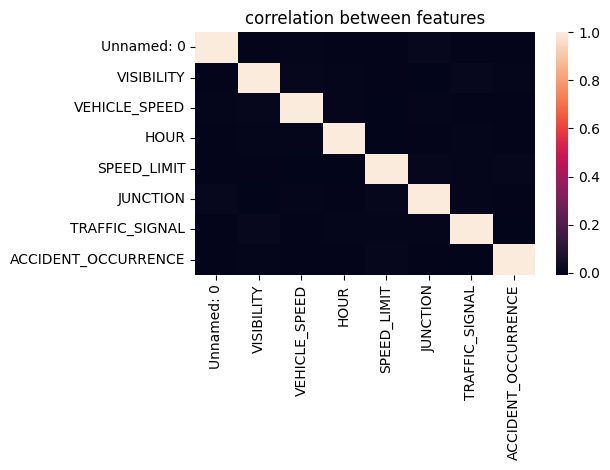

In [16]:
# STEP 8
print('Checking correlation between numerical features')
corr = df.corr(numeric_only=True)
print(corr.sample().to_string())

plt.Figure(figsize=(10,6))
sns.heatmap(corr)
plt.title('correlation between features')
plt.tight_layout()
plt.show()

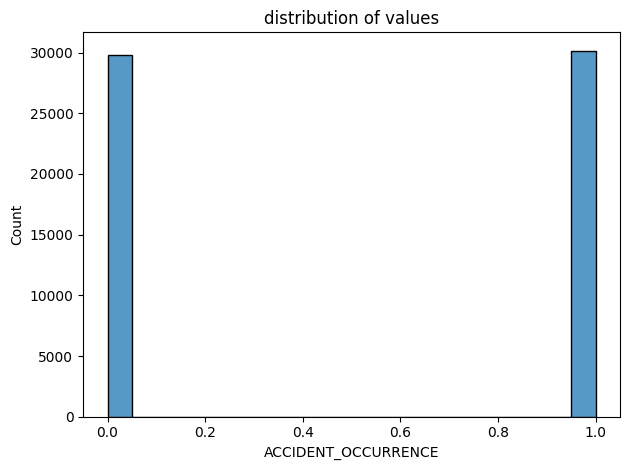

In [ ]:
# STEP 9 DISTRIBUTION VALUES

plt.Figure(figsize=(10,6))
sns.histplot(df['ACCIDENT_OCCURRENCE'])
plt.title('distribution of values')
plt.tight_layout()
plt.show()

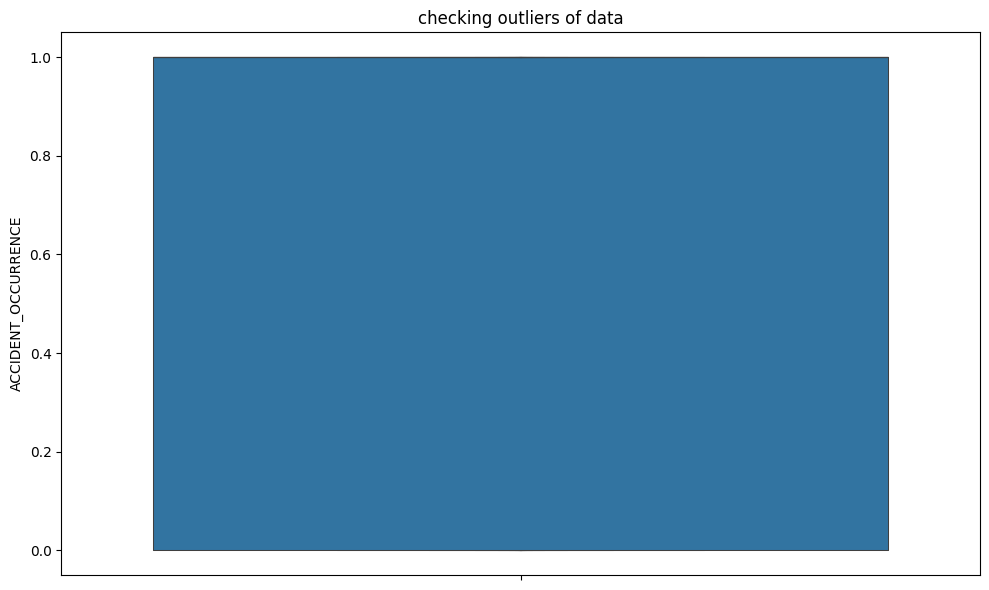

In [11]:
# STEP 10 CHECKING OUTLIERS

plt.figure(figsize=(10,6))
sns.boxenplot(df['ACCIDENT_OCCURRENCE'])
plt.title('checking outliers of data')
plt.tight_layout()
plt.show()

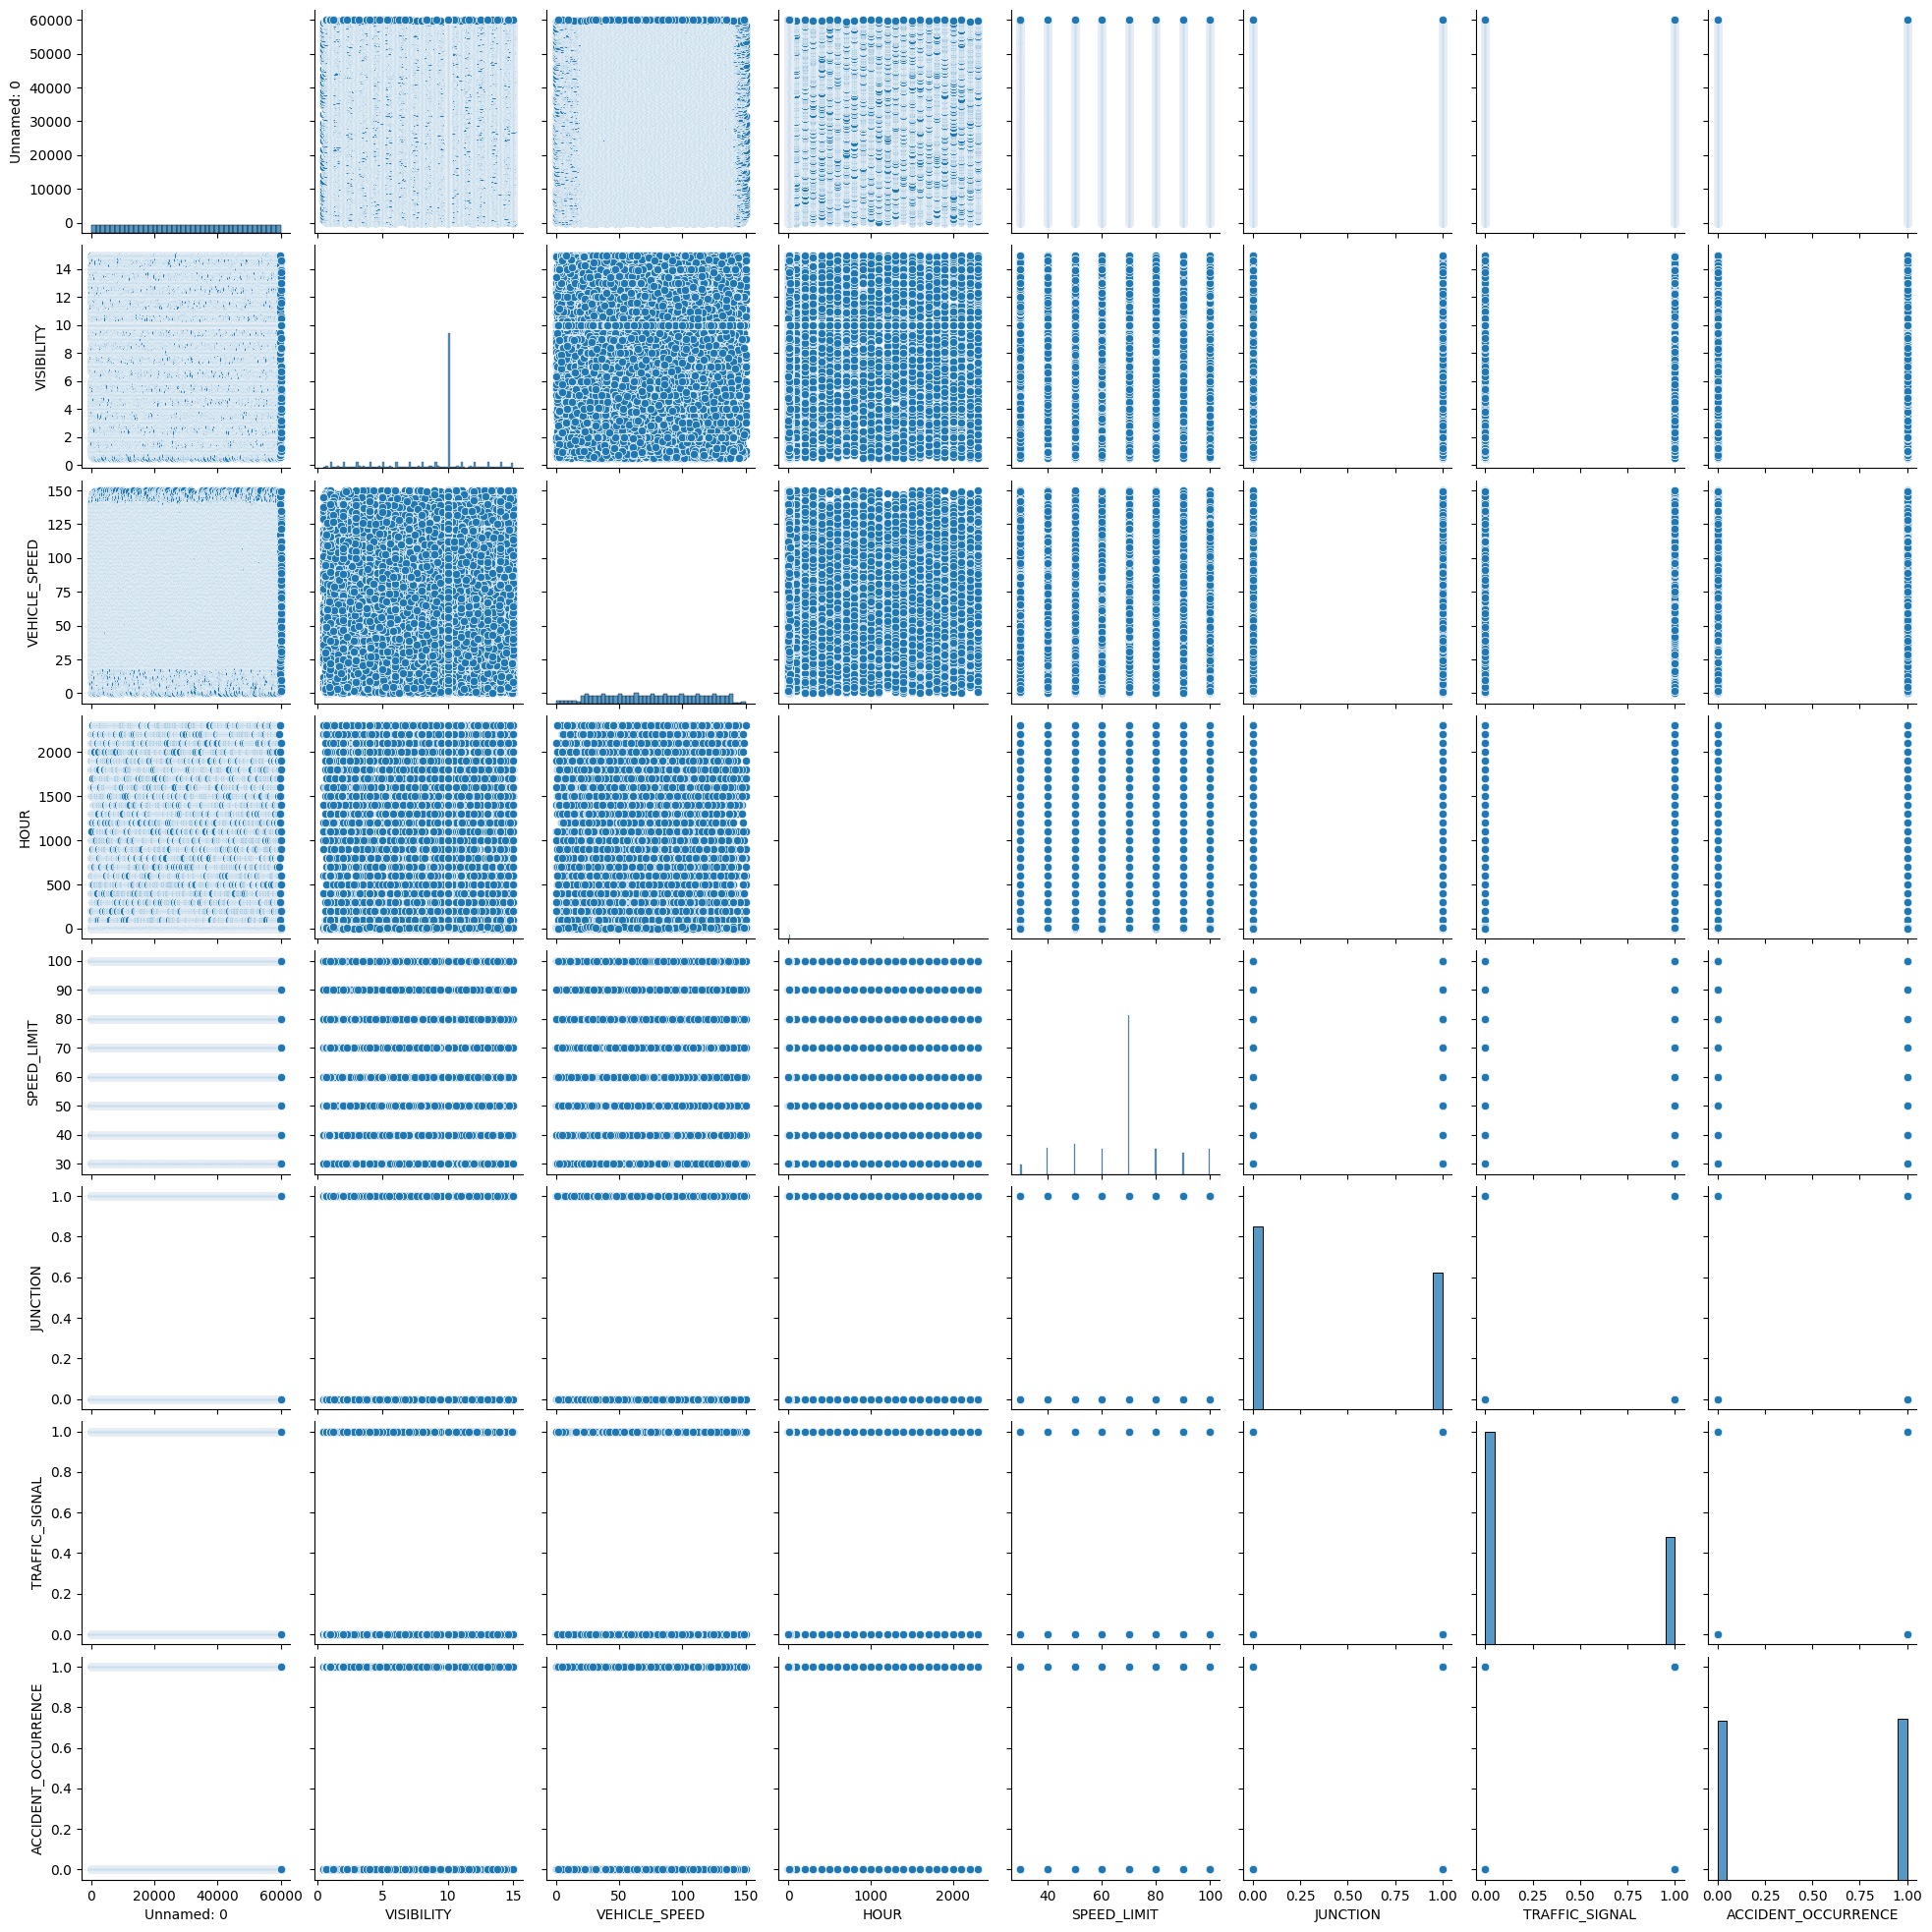

In [ ]:
# STEP 11 RELATION COMPLETE TABLE

plt.figure(figsize=(10,6))
sns.pairplot(df)
plt.tight_layout()
plt.show()

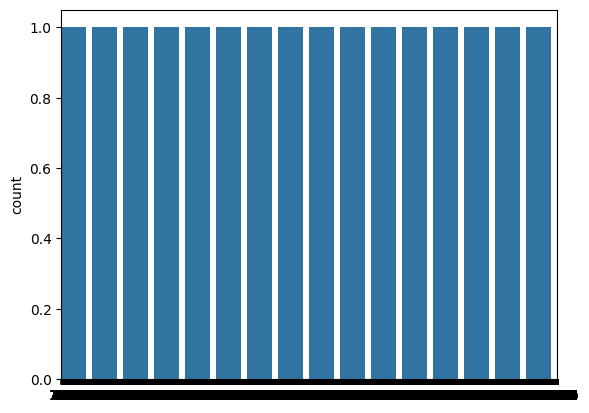

In [ ]:
#STEP 12 COUNT VALUES

sns.countplot(df['ACCIDENT_OCCURRENCE'])
plt.show()